Web Scrapping

In [ ]:
#Mengambil isi halaman web (HTML)
import requests

url = 'https://quotes.toscrape.com/page/2/'

response = requests.get(url)

print(response.status_code)

200


In [ ]:
#Mengubah HTML menjadi objek yang bisa dibaca python
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text,'html.parser')

print(soup.title.text)

Quotes to Scrape


In [ ]:
#Mengambil semua quote, author, dan tags.
quotes = soup.find_all('div', class_='quote')

print(len(quotes))

10


In [ ]:
#Membaca setiap quote satu per satu
import pandas as pd

data = []

for quote in quotes:

  text = quote.find("span", class_="text").text
  author = quote.find("small", class_="author").text

  tags = quote.find_all("a", class_="tag")
  tag_list = [tag.text for tag in tags]

  data.append({
      "Quote": text,
      "Author" : author,
      "Tags" : "," .join(tag_list)
  })

In [ ]:
#Membuat DF
df = pd.DataFrame(data)

print(df.head())

                                               Quote           Author Tags
0  “This life is what you make it. No matter what...   Marilyn Monroe     
1  “It takes a great deal of bravery to stand up ...     J.K. Rowling     
2  “If you can't explain it to a six year old, yo...  Albert Einstein     
3  “You may not be her first, her last, or her on...       Bob Marley     
4  “I like nonsense, it wakes up the brain cells....        Dr. Seuss     


In [ ]:
#Simpan DF
df.to_csv('quotes.csv', index=False)

print('Data berhasil disimpan!')

Data berhasil disimpan!


In [ ]:
#Tampilkan DF
print(df)

                                               Quote               Author Tags
0  “This life is what you make it. No matter what...       Marilyn Monroe     
1  “It takes a great deal of bravery to stand up ...         J.K. Rowling     
2  “If you can't explain it to a six year old, yo...      Albert Einstein     
3  “You may not be her first, her last, or her on...           Bob Marley     
4  “I like nonsense, it wakes up the brain cells....            Dr. Seuss     
5  “I may not have gone where I intended to go, b...        Douglas Adams     
6  “The opposite of love is not hate, it's indiff...          Elie Wiesel     
7  “It is not a lack of love, but a lack of frien...  Friedrich Nietzsche     
8  “Good friends, good books, and a sleepy consci...           Mark Twain     
9  “Life is what happens to us while we are makin...       Allen Saunders     


EDA

In [ ]:
#Baca data
df = pd.read_csv('quotes.csv')
print(df.head())

                                               Quote           Author  Tags
0  “This life is what you make it. No matter what...   Marilyn Monroe   NaN
1  “It takes a great deal of bravery to stand up ...     J.K. Rowling   NaN
2  “If you can't explain it to a six year old, yo...  Albert Einstein   NaN
3  “You may not be her first, her last, or her on...       Bob Marley   NaN
4  “I like nonsense, it wakes up the brain cells....        Dr. Seuss   NaN


In [ ]:
#Informasi data
df.shape
df.info()
df.dtypes
df.head()
df.tail(3)
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Quote   10 non-null     object 
 1   Author  10 non-null     object 
 2   Tags    0 non-null      float64
dtypes: float64(1), object(2)
memory usage: 372.0+ bytes


Index(['Quote', 'Author', 'Tags'], dtype='object')

In [ ]:
#Statistik dasar
df.describe(include='object')

,Quote,Author
count,10,10
unique,10,10
top,“This life is what you make it. No matter what...,Marilyn Monroe
freq,1,1


In [ ]:
#Mengecek missing value
df.isnull().sum()

,0
Quote,0
Author,0
Tags,10


In [ ]:
#Mengetahui penulis yang sering muncul
df['Author'].value_counts()

,count
Author,
Marilyn Monroe,1
J.K. Rowling,1
Albert Einstein,1
Bob Marley,1
Dr. Seuss,1
Douglas Adams,1
Elie Wiesel,1
Friedrich Nietzsche,1
Mark Twain,1


<Axes: xlabel='count', ylabel='Author'>

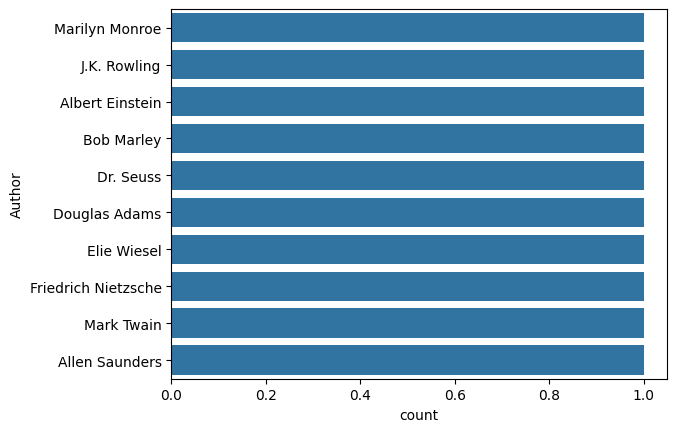

In [ ]:
#Visualisasi data
import seaborn as sns

sns.countplot(data=df, y='Author')